# Selecting `n_per_class` for V2 Sampling

## Context

V1 trained on 8 pitchers with a random train/test split. Because the same pitchers
appear in both train and test, the model partially learned pitcher identity rather
than pitch mechanics, producing inflated F1 scores (0.98–0.99).

V2 expands to all MLB pitchers from the 2023 season. To keep classes balanced and
training tractable, we cap each pitch type at N rows sampled globally. This notebook
documents how N was chosen.

## Approach

We use July 2023 as a representative single month to:
1. See how many pitches of each type exist across all MLB pitchers
2. Identify the rarest pitch type. N cannot exceed that count without oversampling
3. Choose an N that keeps all classes well-represented while staying within the natural data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import yaml

with open('../configs/data.yaml') as f:
    config = yaml.safe_load(f)

EXCLUDE = set(config['filtering']['exclude_pitch_types'])
MIN_COUNT = config['filtering']['min_pitch_count']


In [2]:
df = pd.read_csv('../data/raw/july_2023_sample.csv', low_memory=False)
print(f'Total rows: {len(df):,}')
print(f'Unique pitch types (raw): {sorted(df["pitch_type"].dropna().unique())}')


Total rows: 108,240
Unique pitch types (raw): ['CH', 'CS', 'CU', 'EP', 'FA', 'FC', 'FF', 'FO', 'FS', 'KC', 'PO', 'SC', 'SI', 'SL', 'ST', 'SV']


In [3]:
df_filtered = df[~df['pitch_type'].isin(EXCLUDE)].copy()
df_filtered = df_filtered[df_filtered['pitch_type'].notna()]

counts = df_filtered['pitch_type'].value_counts().sort_values()
counts = counts[counts >= MIN_COUNT]

print('Pitch type counts (July 2023, all MLB pitchers):')
print(counts.to_string())
print(f'\nRarest qualifying pitch type: {counts.index[0]} — {counts.iloc[0]:,} pitches')


Pitch type counts (July 2023, all MLB pitchers):
pitch_type
KC     2020
FS     2434
ST     6896
CU     7723
FC     8825
CH    10889
SI    16773
SL    17053
FF    34191

Rarest qualifying pitch type: KC — 2,020 pitches


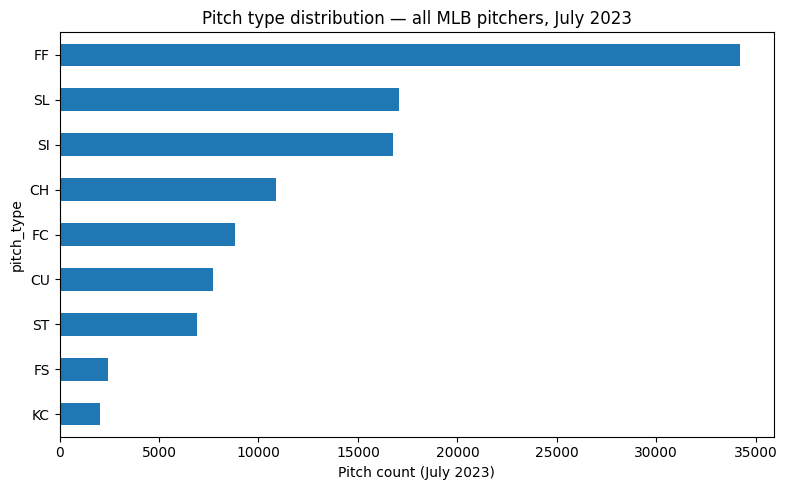

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
counts.sort_values().plot(kind='barh', ax=ax)
ax.set_xlabel('Pitch count (July 2023)')
ax.set_title('Pitch type distribution — all MLB pitchers, July 2023')
plt.tight_layout()
plt.savefig('../results/figures/july_2023_pitch_distribution.png', dpi=150)
plt.show()


## Decision

- EP, FO, FA, and SV were excluded via `exclude_pitch_types` in `configs/data.yaml` these are novelty, extinct, or ambiguous pitch types with fewer than 500 pitches in a full month of MLB data and are not representative of real pitch mechanics.
- After exclusions, the rarest qualifying pitch type is **KC** with **2,020** pitches in July 2023.
- Chosen value: **`n_per_class = 2000`**
- Reasoning: 2,000 is at the natural ceiling set by KC. It keeps all classes equally
  represented without oversampling any pitch type, and provides enough samples per class
  for stable model training.

This value will be set as `sampling.n_per_class` in `configs/data.yaml`.
